# Bootstrap Analysis for Self-Prioritization Effect (v4)

**Updates in v4**:
1. Legend integrated into title area to avoid blocking the plot
2. Two legend styles provided:
   - Style 1: Colored squares after title text
   - Style 2: Subtitle below main title
3. Both original and aligned versions

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set APA style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Define paths and load data
data_path = Path("D:/GitHub_programe/GitHub/SPE_Database/1_Data")
output_path = Path("D:/GitHub_programe/GitHub/SPE_Database/3_Reports/Bootstrap")
output_path.mkdir(exist_ok=True)

# Load all Clean.csv files
clean_files = list(data_path.rglob("*_Clean.csv"))
print(f"Found {len(clean_files)} Clean.csv files")

all_data = []
for file_path in clean_files:
    try:
        df = pd.read_csv(file_path)
        df['Source'] = file_path.stem
        all_data.append(df)
    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")

merged_df = pd.concat(all_data, ignore_index=True)
print(f"Total merged data: {len(merged_df)} rows")

Found 72 Clean.csv files
Total merged data: 1591899 rows


In [3]:
# Prepare data
has_label = 'Label_Standardized_Identity' in merged_df.columns
if not has_label:
    merged_df['Label_Standardized_Identity'] = merged_df['Shape_Standardized_Identity']

mismatch_df = merged_df[merged_df['Matching'] == 'Nonmatching'].copy()
print(f"Mismatch trials: {len(mismatch_df)} rows, {mismatch_df['Subject'].nunique()} participants")

Mismatch trials: 853015 rows, 1676 participants


In [4]:
# Define helper functions
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (mean1 - mean2) / pooled_sd if pooled_sd != 0 else np.nan

def filter_valid_subjects(df, identity_column):
    valid_subjects = []
    for subject, subj_df in df.groupby('Subject'):
        identities = set(subj_df[identity_column].dropna().unique())
        if 'Self' in identities and 'Stranger' in identities and len(identities) >= 3:
            valid_subjects.append(subject)
    return valid_subjects

print("Helper functions defined!")

Helper functions defined!


In [5]:
# Define data processing functions
def process_data_strict(df, analysis_type='Shape'):
    if analysis_type == 'Shape':
        identity_column = 'Shape_Standardized_Identity'
        secondary_column = 'Label_Standardized_Identity'
    else:
        identity_column = 'Label_Standardized_Identity'
        secondary_column = 'Shape_Standardized_Identity'
    
    valid_subjects = filter_valid_subjects(df, identity_column)
    df_filtered = df[df['Subject'].isin(valid_subjects)].copy()
    
    df_filtered['Primary'] = df_filtered[identity_column].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    df_filtered['Secondary'] = df_filtered[secondary_column].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    
    mask = (
        (df_filtered['Primary'] == 'Self') |
        ((df_filtered['Primary'] == 'Stranger') & (df_filtered['Secondary'] != 'Self')) |
        (df_filtered['Primary'] == 'Other')
    )
    return df_filtered[mask].copy()

def process_data_loose(df, analysis_type='Shape'):
    identity_column = 'Shape_Standardized_Identity' if analysis_type == 'Shape' else 'Label_Standardized_Identity'
    df_filtered = df.copy()
    df_filtered['Primary'] = df_filtered[identity_column].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    return df_filtered[df_filtered['Primary'].isin(['Self', 'Stranger'])].copy()

print("Data processing functions defined!")

Data processing functions defined!


In [6]:
# Define analysis and bootstrap functions
def calculate_cohens_d_per_subject(df, measure='RT', min_trials=2):
    results = []
    for subject, subj_df in df.groupby('Subject'):
        self_data = subj_df[subj_df['Primary'] == 'Self']
        stranger_data = subj_df[subj_df['Primary'] == 'Stranger']
        
        if measure == 'RT':
            self_values = self_data[self_data['ACC'] == 1]['RT_ms'].dropna().values
            stranger_values = stranger_data[stranger_data['ACC'] == 1]['RT_ms'].dropna().values
        else:
            self_values = self_data['ACC'].dropna().values
            stranger_values = stranger_data['ACC'].dropna().values
        
        if len(self_values) < min_trials or len(stranger_values) < min_trials:
            continue
        
        d = cohens_d(stranger_values, self_values) if measure == 'RT' else cohens_d(self_values, stranger_values)
        if not np.isnan(d):
            results.append({'Subject': subject, 'Cohens_d': d})
    return pd.DataFrame(results)

def bootstrap_analysis(cohens_d_values, n_bootstrap=500, min_n=10, step=10, max_n=None):
    total_n = len(cohens_d_values)
    if total_n < min_n:
        return pd.DataFrame()
    max_n = min(max_n, total_n) if max_n else total_n
    sample_sizes = list(range(min_n, max_n + 1, step))
    if max_n % step != 0 and max_n not in sample_sizes:
        sample_sizes.append(max_n)
    sample_sizes = sorted(set(sample_sizes))
    
    results = []
    for n in sample_sizes:
        bootstrap_means = [np.mean(np.random.choice(cohens_d_values, size=n, replace=True)) for _ in range(n_bootstrap)]
        results.append({
            'SampleSize': n,
            'Mean_d': np.mean(bootstrap_means),
            'CI_lower': np.percentile(bootstrap_means, 2.5),
            'CI_upper': np.percentile(bootstrap_means, 97.5)
        })
    return pd.DataFrame(results)

print("Analysis functions defined!")

Analysis functions defined!


In [7]:
# Run analyses
def run_analysis(data_filtered, filtering_type='Strict', n_bootstrap=500):
    results = {}
    
    print(f"\n=== {filtering_type} Filtering ===")
    
    # RT
    data_rt = data_filtered[data_filtered['Matching'] == 'Nonmatching'].copy()
    if filtering_type == 'Strict':
        rt_shape_data = process_data_strict(data_rt, 'Shape')
        rt_label_data = process_data_strict(data_rt, 'Label')
    else:
        rt_shape_data = process_data_loose(data_rt, 'Shape')
        rt_label_data = process_data_loose(data_rt, 'Label')
    
    rt_shape_cohens = calculate_cohens_d_per_subject(rt_shape_data, 'RT')
    rt_label_cohens = calculate_cohens_d_per_subject(rt_label_data, 'RT')
    print(f"RT - Shape: {len(rt_shape_cohens)}, Label: {len(rt_label_cohens)}")
    
    rt_max_n = min(len(rt_shape_cohens), len(rt_label_cohens))
    rt_shape_boot = bootstrap_analysis(rt_shape_cohens['Cohens_d'].values, n_bootstrap) if len(rt_shape_cohens) > 0 else pd.DataFrame()
    rt_label_boot = bootstrap_analysis(rt_label_cohens['Cohens_d'].values, n_bootstrap) if len(rt_label_cohens) > 0 else pd.DataFrame()
    rt_shape_boot_aligned = bootstrap_analysis(rt_shape_cohens['Cohens_d'].values, n_bootstrap, max_n=rt_max_n) if len(rt_shape_cohens) > 0 else pd.DataFrame()
    rt_label_boot_aligned = bootstrap_analysis(rt_label_cohens['Cohens_d'].values, n_bootstrap, max_n=rt_max_n) if len(rt_label_cohens) > 0 else pd.DataFrame()
    
    for df in [rt_shape_boot, rt_label_boot, rt_shape_boot_aligned, rt_label_boot_aligned]:
        if not df.empty:
            df['Identity'] = 'Shape' if df is rt_shape_boot or df is rt_shape_boot_aligned else 'Label'
    
    # ACC
    if filtering_type == 'Strict':
        acc_shape_data = process_data_strict(data_filtered, 'Shape')
        acc_label_data = process_data_strict(data_filtered, 'Label')
    else:
        acc_shape_data = process_data_loose(data_filtered, 'Shape')
        acc_label_data = process_data_loose(data_filtered, 'Label')
    
    acc_shape_cohens = calculate_cohens_d_per_subject(acc_shape_data, 'ACC')
    acc_label_cohens = calculate_cohens_d_per_subject(acc_label_data, 'ACC')
    print(f"ACC - Shape: {len(acc_shape_cohens)}, Label: {len(acc_label_cohens)}")
    
    acc_max_n = min(len(acc_shape_cohens), len(acc_label_cohens))
    acc_shape_boot = bootstrap_analysis(acc_shape_cohens['Cohens_d'].values, n_bootstrap) if len(acc_shape_cohens) > 0 else pd.DataFrame()
    acc_label_boot = bootstrap_analysis(acc_label_cohens['Cohens_d'].values, n_bootstrap) if len(acc_label_cohens) > 0 else pd.DataFrame()
    acc_shape_boot_aligned = bootstrap_analysis(acc_shape_cohens['Cohens_d'].values, n_bootstrap, max_n=acc_max_n) if len(acc_shape_cohens) > 0 else pd.DataFrame()
    acc_label_boot_aligned = bootstrap_analysis(acc_label_cohens['Cohens_d'].values, n_bootstrap, max_n=acc_max_n) if len(acc_label_cohens) > 0 else pd.DataFrame()
    
    for df in [acc_shape_boot, acc_label_boot, acc_shape_boot_aligned, acc_label_boot_aligned]:
        if not df.empty:
            df['Identity'] = 'Shape' if df is acc_shape_boot or df is acc_shape_boot_aligned else 'Label'
    
    return {
        'rt_bootstrap': pd.concat([rt_shape_boot, rt_label_boot], ignore_index=True),
        'rt_bootstrap_aligned': pd.concat([rt_shape_boot_aligned, rt_label_boot_aligned], ignore_index=True),
        'acc_bootstrap': pd.concat([acc_shape_boot, acc_label_boot], ignore_index=True),
        'acc_bootstrap_aligned': pd.concat([acc_shape_boot_aligned, acc_label_boot_aligned], ignore_index=True)
    }

# Run
strict_results = run_analysis(mismatch_df, 'Strict', 500)
loose_results = run_analysis(mismatch_df, 'Loose', 500)


=== Strict Filtering ===
RT - Shape: 792, Label: 610
ACC - Shape: 782, Label: 590

=== Loose Filtering ===
RT - Shape: 964, Label: 813
ACC - Shape: 954, Label: 800


In [8]:
# Create figure function - Style 1: Legend as colored squares after title
def create_figure_style1(strict_rt, strict_acc, loose_rt, loose_acc, version='original'):
    shape_color = '#2E86AB'
    label_color = '#A23B72'
    
    x_min, x_max = 0, 500
    y_min, y_max = -0.4, 0.4
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    plot_configs = [
        (axes[0, 0], strict_rt, 'RT', 'Strict'),
        (axes[0, 1], strict_acc, 'ACC', 'Strict'),
        (axes[1, 0], loose_rt, 'RT', 'Loose'),
        (axes[1, 1], loose_acc, 'ACC', 'Loose'),
    ]
    
    for ax, data, measure, filtering in plot_configs:
        ax.set_facecolor('white')
        ax.grid(False)
        
        if data.empty:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes, fontsize=14)
            continue
        
        for identity in ['Shape', 'Label']:
            subset = data[data['Identity'] == identity]
            if subset.empty:
                continue
            color = shape_color if identity == 'Shape' else label_color
            ax.plot(subset['SampleSize'], subset['Mean_d'], color=color, linewidth=2, label=identity)
            ax.fill_between(subset['SampleSize'], subset['CI_lower'], subset['CI_upper'], color=color, alpha=0.2)
            ax.scatter(subset['SampleSize'], subset['Mean_d'], color=color, s=20, zorder=5)
        
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        y_label = "Cohen's d (Stranger - Self)" if measure == 'RT' else "Cohen's d (Self - Stranger)"
        subplot_label = ('A' if filtering == 'Strict' else 'C') if measure == 'RT' else ('B' if filtering == 'Strict' else 'D')
        
        ax.set_xlabel('Sample Size', fontsize=12, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
        
        # Title
        title_text = f"SPE calculated by {filtering.lower()} approach ({measure})"
        ax.set_title(title_text, fontsize=12, fontweight='bold', family='Times New Roman', loc='left')
        
        # Legend as colored squares at right side of title area
        ax.text(0.98, 1.02, '■', transform=ax.transAxes, fontsize=12, color=shape_color, fontweight='bold', ha='right', va='bottom')
        ax.text(1.02, 1.02, 'Shape', transform=ax.transAxes, fontsize=10, color='black', ha='right', va='bottom')
        ax.text(1.08, 1.02, '■', transform=ax.transAxes, fontsize=12, color=label_color, fontweight='bold', ha='right', va='bottom')
        ax.text(1.12, 1.02, 'Label', transform=ax.transAxes, fontsize=10, color='black', ha='right', va='bottom')
        
        # Subplot label
        ax.text(-0.08, 1.15, subplot_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    filename = f'combined_figures_style1_{version}.png'
    plt.savefig(output_path / filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print(f"Saved: {filename}")

print("Figure function (Style 1) defined!")

Figure function (Style 1) defined!


In [9]:
# Create figure function - Style 2: Legend below title as subtitle
def create_figure_style2(strict_rt, strict_acc, loose_rt, loose_acc, version='original'):
    shape_color = '#2E86AB'
    label_color = '#A23B72'
    
    x_min, x_max = 0, 500
    y_min, y_max = -0.4, 0.4
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    plot_configs = [
        (axes[0, 0], strict_rt, 'RT', 'Strict'),
        (axes[0, 1], strict_acc, 'ACC', 'Strict'),
        (axes[1, 0], loose_rt, 'RT', 'Loose'),
        (axes[1, 1], loose_acc, 'ACC', 'Loose'),
    ]
    
    for ax, data, measure, filtering in plot_configs:
        ax.set_facecolor('white')
        ax.grid(False)
        
        if data.empty:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes, fontsize=14)
            continue
        
        for identity in ['Shape', 'Label']:
            subset = data[data['Identity'] == identity]
            if subset.empty:
                continue
            color = shape_color if identity == 'Shape' else label_color
            ax.plot(subset['SampleSize'], subset['Mean_d'], color=color, linewidth=2, label=identity)
            ax.fill_between(subset['SampleSize'], subset['CI_lower'], subset['CI_upper'], color=color, alpha=0.2)
            ax.scatter(subset['SampleSize'], subset['Mean_d'], color=color, s=20, zorder=5)
        
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        y_label = "Cohen's d (Stranger - Self)" if measure == 'RT' else "Cohen's d (Self - Stranger)"
        subplot_label = ('A' if filtering == 'Strict' else 'C') if measure == 'RT' else ('B' if filtering == 'Strict' else 'D')
        
        ax.set_xlabel('Sample Size', fontsize=12, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
        
        # Main title
        title_text = f"SPE calculated by {filtering.lower()} approach"
        ax.set_title(title_text, fontsize=13, fontweight='bold', family='Times New Roman', pad=20)
        
        # Subtitle with measure and legend
        ax.text(0.5, 1.02, f'({measure})', transform=ax.transAxes, fontsize=10, ha='right', va='bottom', color='black')
        ax.text(0.52, 1.02, ' ■', transform=ax.transAxes, fontsize=12, ha='left', va='bottom', color=shape_color, fontweight='bold')
        ax.text(0.58, 1.02, ' Shape  ', transform=ax.transAxes, fontsize=10, ha='left', va='bottom', color='black')
        ax.text(0.70, 1.02, '■', transform=ax.transAxes, fontsize=12, ha='left', va='bottom', color=label_color, fontweight='bold')
        ax.text(0.73, 1.02, ' Label', transform=ax.transAxes, fontsize=10, ha='left', va='bottom', color='black')
        
        # Subplot label
        ax.text(-0.08, 1.15, subplot_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    filename = f'combined_figures_style2_{version}.png'
    plt.savefig(output_path / filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print(f"Saved: {filename}")

print("Figure function (Style 2) defined!")

Figure function (Style 2) defined!



=== STYLE 1: Legend as colored squares after title ===

Original sample sizes:


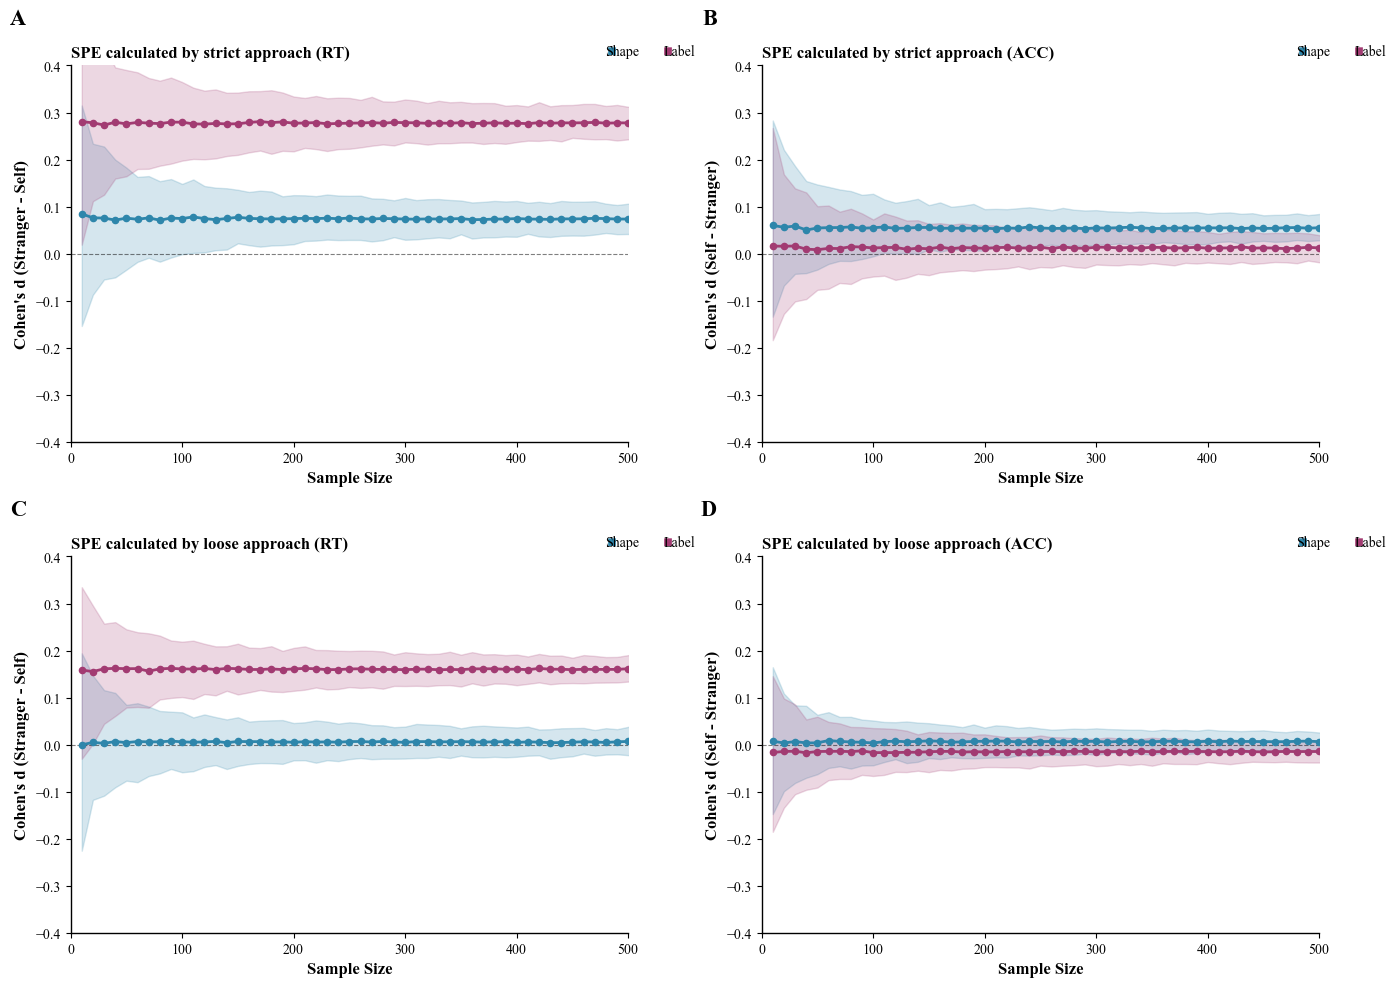

Saved: combined_figures_style1_original.png

Aligned sample sizes:


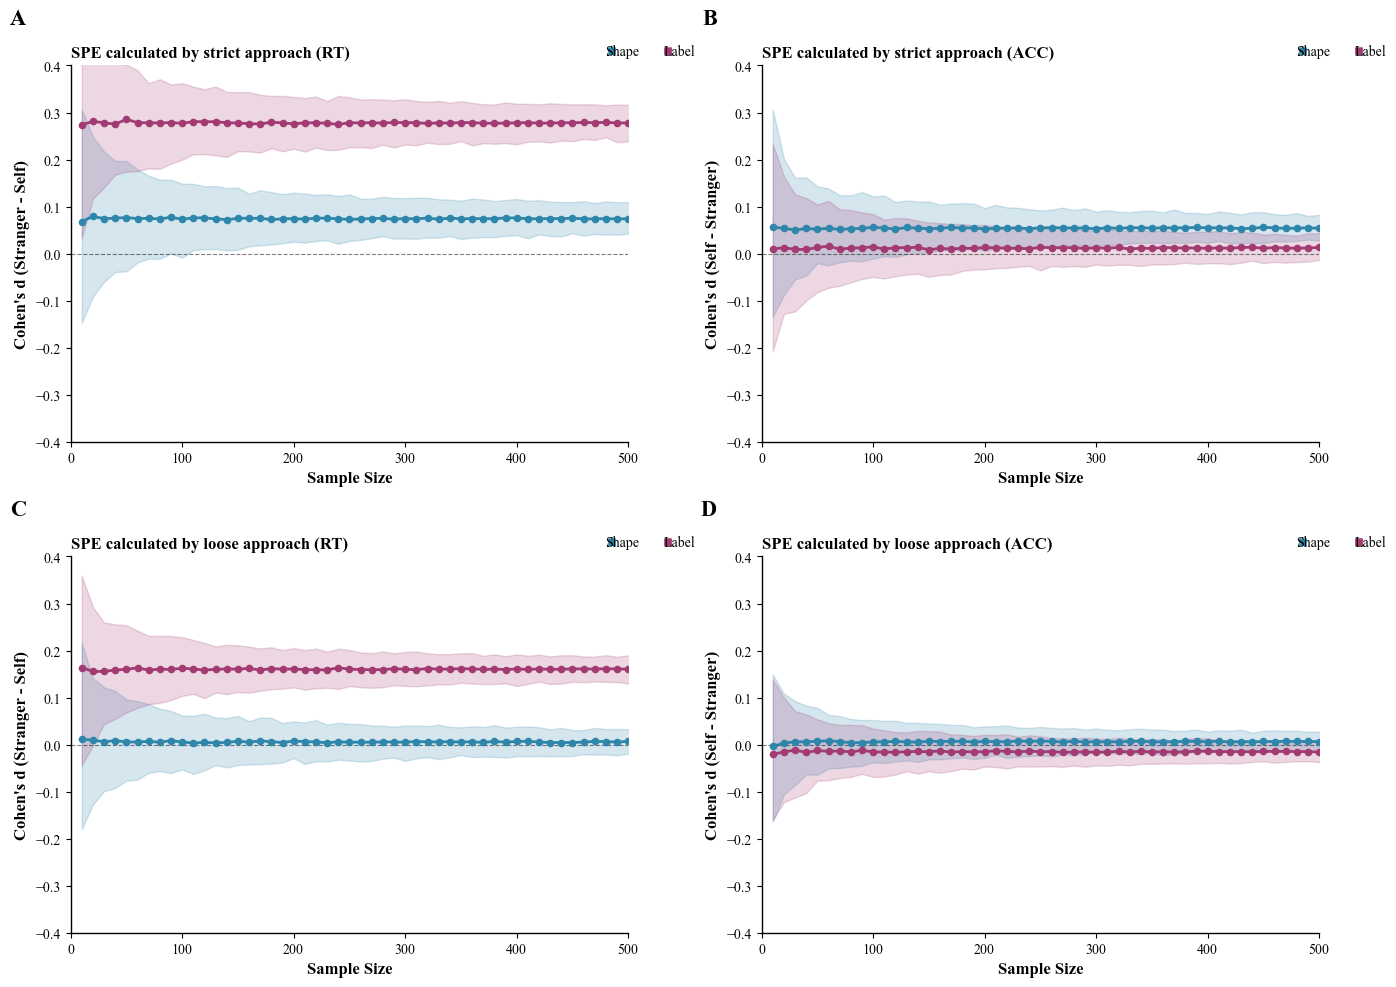

Saved: combined_figures_style1_aligned.png


In [10]:
# Generate Style 1 figures
print("\n=== STYLE 1: Legend as colored squares after title ===")
print("\nOriginal sample sizes:")
create_figure_style1(strict_results['rt_bootstrap'], strict_results['acc_bootstrap'], 
                    loose_results['rt_bootstrap'], loose_results['acc_bootstrap'], 'original')

print("\nAligned sample sizes:")
create_figure_style1(strict_results['rt_bootstrap_aligned'], strict_results['acc_bootstrap_aligned'], 
                    loose_results['rt_bootstrap_aligned'], loose_results['acc_bootstrap_aligned'], 'aligned')


=== STYLE 2: Legend below title as subtitle ===

Original sample sizes:


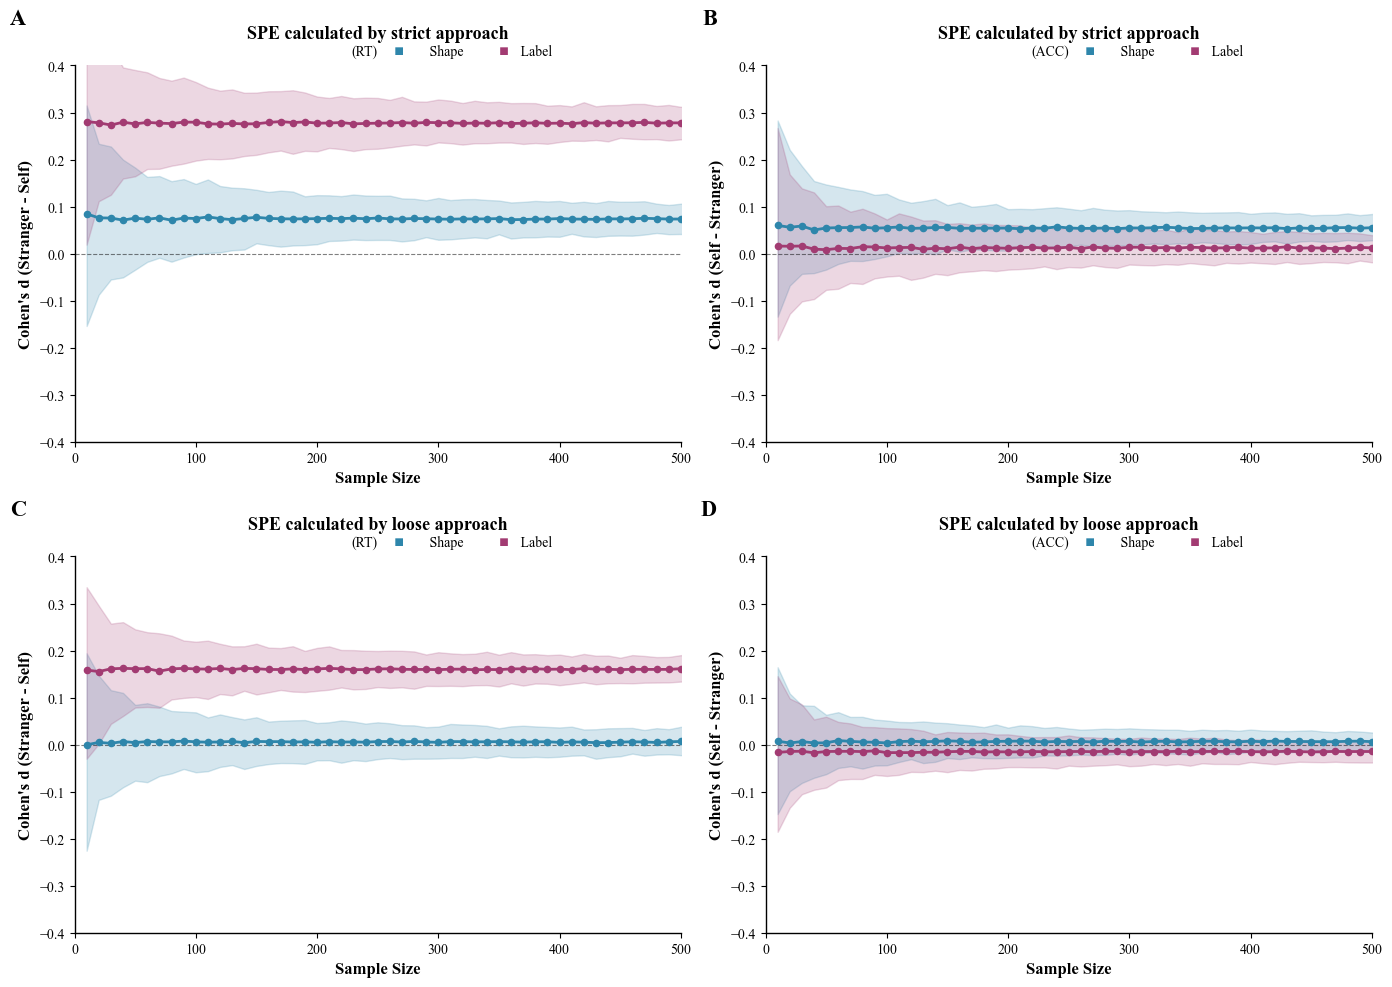

Saved: combined_figures_style2_original.png

Aligned sample sizes:


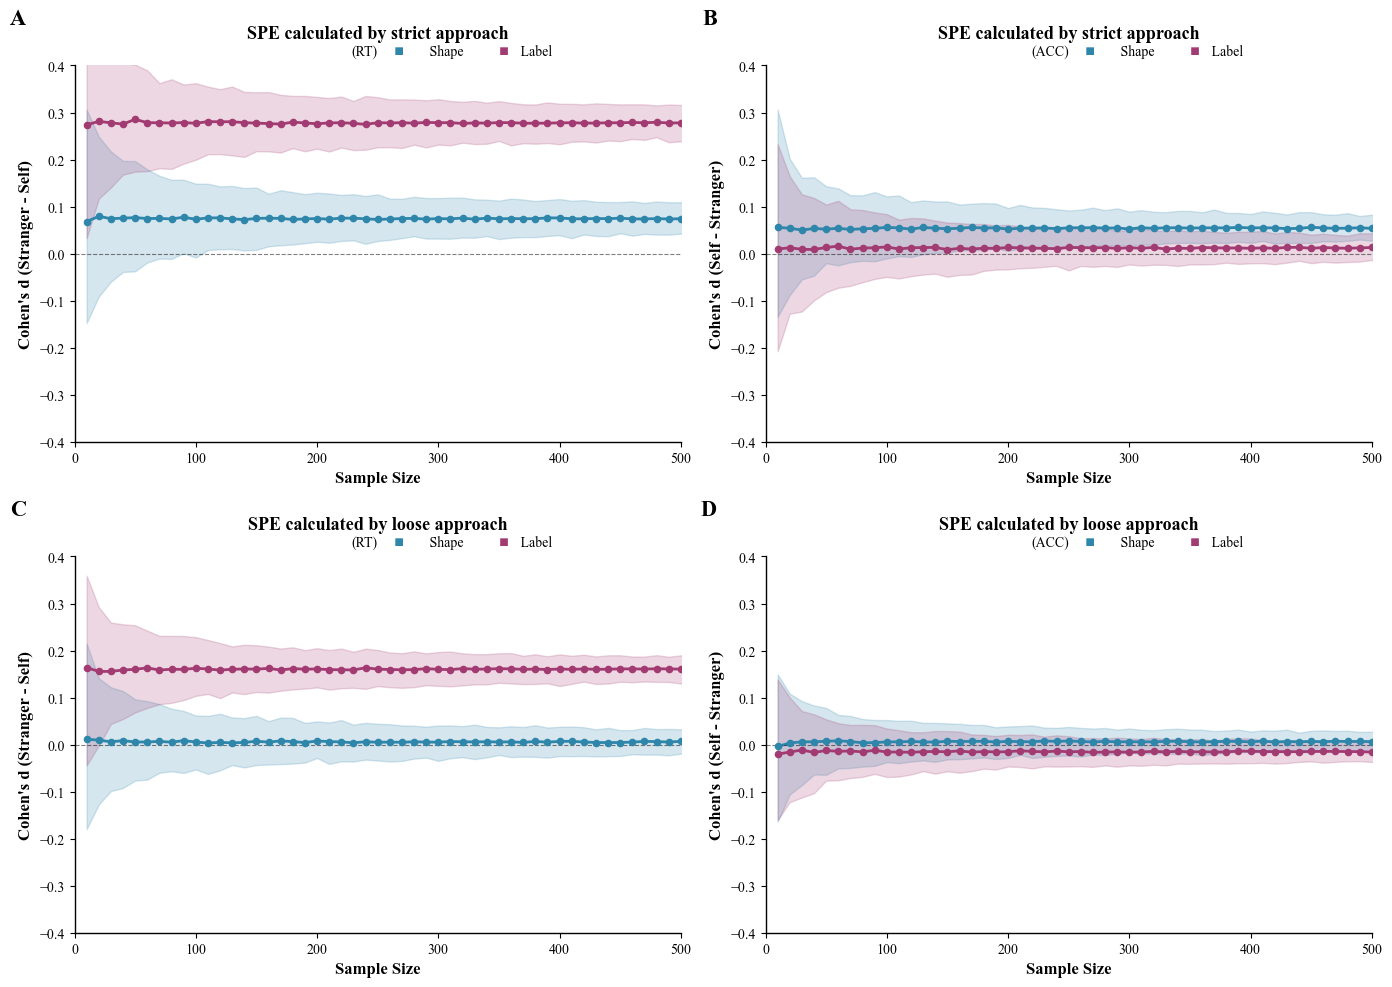

Saved: combined_figures_style2_aligned.png


In [11]:
# Generate Style 2 figures
print("\n=== STYLE 2: Legend below title as subtitle ===")
print("\nOriginal sample sizes:")
create_figure_style2(strict_results['rt_bootstrap'], strict_results['acc_bootstrap'], 
                    loose_results['rt_bootstrap'], loose_results['acc_bootstrap'], 'original')

print("\nAligned sample sizes:")
create_figure_style2(strict_results['rt_bootstrap_aligned'], strict_results['acc_bootstrap_aligned'], 
                    loose_results['rt_bootstrap_aligned'], loose_results['acc_bootstrap_aligned'], 'aligned')

In [12]:
# Save results
print("\n=== SAVING RESULTS ===")

strict_results['rt_bootstrap'].to_csv(output_path / 'bootstrap_rt_strict_original.csv', index=False)
strict_results['acc_bootstrap'].to_csv(output_path / 'bootstrap_acc_strict_original.csv', index=False)
loose_results['rt_bootstrap'].to_csv(output_path / 'bootstrap_rt_loose_original.csv', index=False)
loose_results['acc_bootstrap'].to_csv(output_path / 'bootstrap_acc_loose_original.csv', index=False)

strict_results['rt_bootstrap_aligned'].to_csv(output_path / 'bootstrap_rt_strict_aligned.csv', index=False)
strict_results['acc_bootstrap_aligned'].to_csv(output_path / 'bootstrap_acc_strict_aligned.csv', index=False)
loose_results['rt_bootstrap_aligned'].to_csv(output_path / 'bootstrap_rt_loose_aligned.csv', index=False)
loose_results['acc_bootstrap_aligned'].to_csv(output_path / 'bootstrap_acc_loose_aligned.csv', index=False)

print("All results saved!")


=== SAVING RESULTS ===
All results saved!


In [13]:
# Summary
print("=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("\nOutput files (300 dpi):")
print("\nStyle 1 (Legend as colored squares after title):")
print("  - combined_figures_style1_original.png")
print("  - combined_figures_style1_aligned.png")
print("\nStyle 2 (Legend below title as subtitle):")
print("  - combined_figures_style2_original.png")
print("  - combined_figures_style2_aligned.png")
print("\nRecommendation: Use Style 1 for cleaner look, Style 2 for more explicit legend.")

ANALYSIS COMPLETE!

Output files (300 dpi):

Style 1 (Legend as colored squares after title):
  - combined_figures_style1_original.png
  - combined_figures_style1_aligned.png

Style 2 (Legend below title as subtitle):
  - combined_figures_style2_original.png
  - combined_figures_style2_aligned.png

Recommendation: Use Style 1 for cleaner look, Style 2 for more explicit legend.


## Summary of Changes (v4)

### Legend Placement

**Style 1**: Legend as colored squares (■) placed at the right side of the title
- Format: `SPE calculated by strict approach (RT)                        ■ Shape  ■ Label`
- Pros: Compact, doesn't block plot area
- Cons: Smaller legend text

**Style 2**: Legend below main title as subtitle
- Format:
  ```
  SPE calculated by strict approach
  (RT)  ■ Shape  ■ Label
  ```
- Pros: More explicit, easier to read
- Cons: Takes more vertical space

### Recommendation
- Use **Style 1** for publication (cleaner, more professional)
- Use **Style 2** for presentations (easier to read)